In [72]:
# imports and  Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('salaries.csv')
df.head(100)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M
...,...,...,...,...,...,...,...,...,...,...,...
95,2025,MI,FT,Data Analyst,79500,USD,79500,US,0,US,M
96,2025,SE,FT,Engineer,183000,USD,183000,US,0,US,M
97,2025,SE,FT,Engineer,125000,USD,125000,US,0,US,M
98,2025,MI,FT,Research Scientist,112003,USD,112003,US,0,US,M


In [73]:
# Getting  info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           151445 non-null  int64 
 1   experience_level    151445 non-null  object
 2   employment_type     151445 non-null  object
 3   job_title           151445 non-null  object
 4   salary              151445 non-null  int64 
 5   salary_currency     151445 non-null  object
 6   salary_in_usd       151445 non-null  int64 
 7   employee_residence  151445 non-null  object
 8   remote_ratio        151445 non-null  int64 
 9   company_location    151445 non-null  object
 10  company_size        151445 non-null  object
dtypes: int64(4), object(7)
memory usage: 12.7+ MB


In [74]:
# Splitting data into features and target variable
x = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

In [75]:
# Encoding categorical variables using Label Encoding

le = LabelEncoder()
x['experience_level'] = le.fit_transform(x['experience_level'])
x['employment_type'] = le.fit_transform(x['employment_type'])
x['job_title'] = le.fit_transform(x['job_title'])
x['company_size'] = le.fit_transform(x['company_size'])
x['salary_currency'] = le.fit_transform(x['salary_currency'])
x['work_year'] = le.fit_transform(x['work_year'])
x['remote_ratio'] = le.fit_transform(x['remote_ratio'])
x['company_location'] = le.fit_transform(x['company_location'])
x['employee_residence'] = le.fit_transform(x['employee_residence'])


In [ ]:
# Splitting data into training and testing sets, training theb base model, and evaluating it
np.random.seed(42)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
model = RandomForestRegressor(n_estimators=100)
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.9952945627562076

In [77]:
# Make perdictions
y_preds = model.predict(x_test)

# Evaluate the model
def evaluate_preds(y_true, y_preds):
    """Evaluate the model predictions"""
    mse = mean_squared_error(y_true, y_preds)
    mae = mean_absolute_error(y_true, y_preds)
    r2 = r2_score(y_true, y_preds)
    print("Model Evaluation")
    print("----------------")
    print(f"Mean Squared Error: {mse}")
    print(f"Mean Absolute Error: {mae}")
    print(f"R^2 Score: {r2}")
evaluate_preds(y_test, y_preds)


Model Evaluation
----------------
Mean Squared Error: 26137877.60673283
Mean Absolute Error: 148.31406748324477
R^2 Score: 0.9952945627562076


In [79]:
# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
# Hyperparameter tuning using RandomizedSearchCV
rf_grid = { 'n_estimators': [10, 100, 200, 500],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'bootstrap': [True, False]}

rs_rf = RandomizedSearchCV(estimator=model,
                           param_distributions=rf_grid,
                           n_iter=100,
                           cv=5,
                           verbose=2,
                           random_state=42,
                           n_jobs=-1)
rs_rf.fit(x_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [10, 100, 200, 500]},
                   random_state=42, verbose=2)

In [ ]:
rs_rf.best_params_

{'n_estimators': 200,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_depth': 10,
 'bootstrap': True}

In [ ]:
# evaluate the randomized search model
rs_rf.score(x_test, y_test)

# Make predictions with the best model
y_preds_best = rs_rf.predict(x_test)
# Evaluate the best model
evaluate_preds(y_test, y_preds_best)

Model Evaluation
----------------
Mean Squared Error: 25503129.134118788
Mean Absolute Error: 384.7013077965178
R^2 Score: 0.9954088325201271


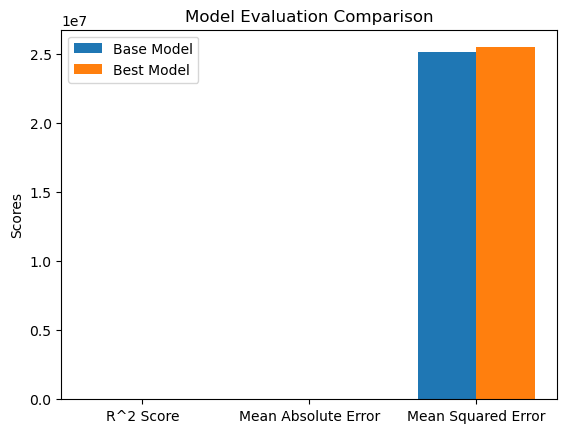

In [ ]:
# plotting R^2 ,MAE and MSE for both the base model and the best model
def plot_evaluation(y_true, y_preds, y_preds_best):
    metrics = ['R^2 Score', 'Mean Absolute Error', 'Mean Squared Error']
    base_model_scores = [r2_score(y_true, y_preds),
                         mean_absolute_error(y_true, y_preds),
                         mean_squared_error(y_true, y_preds)]
    best_model_scores = [r2_score(y_true, y_preds_best),
                         mean_absolute_error(y_true, y_preds_best),
                         mean_squared_error(y_true, y_preds_best)]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, ax = plt.subplots()
    bars1 = ax.bar(x - width/2, base_model_scores, width, label='Base Model')
    bars2 = ax.bar(x + width/2, best_model_scores, width, label='Best Model')
    
    ax.set_ylabel('Scores')
    ax.set_title('Model Evaluation Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    plt.show()
plot_evaluation(y_test, y_preds, y_preds_best)

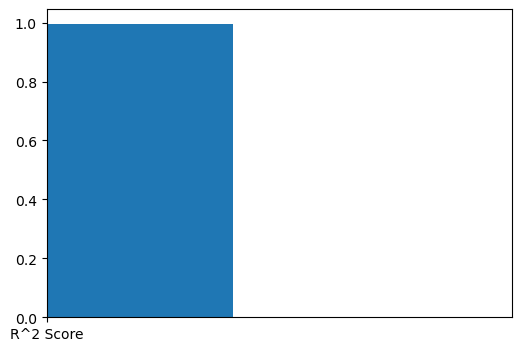

In [ ]:
def plot_r2_score(y_true , y_preds):
    r2 = r2_score(y_true , y_preds)
    plt.figure(figsize=(6,4))
    plt.bar(['R^2 Score'], [r2])
    plt.xlim(0, 1)
    plt.show()
plot_r2_score(y_test , y_preds_best)

In [ ]:
def plot_mae(y_true , y_preds):
    mae = mean_absolute_error(y_true , y_preds)
    plt.figure(figsize=(6,4))
    plt.bar(['Mean Absolute Error'], [mae])
    plt.show()  

plot_mae(y_test , y_preds_best)

In [ ]:
def plot_mse(y_true , y_preds):
    mse = mean_squared_error(y_true , y_preds)
    plt.figure(figsize=(6,4))
    plt.bar(['Mean Squared Error'], [mse])
    plt.show()
plot_mse(y_test , y_preds_best)